In [ ]:
# Last amended: 19th April, 2026

## Ingestion pipeline    
For more on Ingestion pipeline, see [here](https://developers.llamaindex.ai/python/framework/module_guides/loading/ingestion_pipeline/)

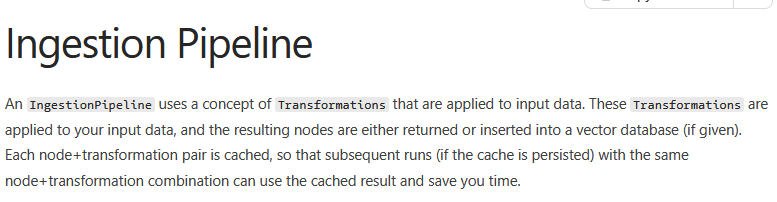

In [1]:
# 1.0
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.ingestion import IngestionPipeline
from llama_index.embeddings.huggingface import HuggingFaceEmbedding


/home/ashok/langchain/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
# 2.0. Load documents
#     Load documents
path = "/mnt/c/Users/ashok/OneDrive/Documents/llamaindex/revised19042026/"
documents = SimpleDirectoryReader(path+"data").load_data()


In [ ]:
# 2.1 Login to huggingface in the terminal
#       to access huggingface

huggingface-cli login

In [25]:
# 3.0
from llama_index.core import Settings
Settings.embed_model = HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5")

# Using Ollama

# 3.1 Call libraries
from llama_index.llms.ollama import Ollama

# 3.2 Configure the model
llm = Ollama(model="llama3.2:latest",
             request_timeout=120.0,
             temperature = 0.9
            )
Settings.llm = llm


2026-04-19 13:26:52,809 - INFO - Load pretrained SentenceTransformer: BAAI/bge-small-en-v1.5
2026-04-19 13:26:56,738 - INFO - 1 prompt is loaded, with the key: query


In [24]:
# 4. Set up the ingestion pipeline with chunking and embedding
pipeline = IngestionPipeline(
    transformations=[
        SentenceSplitter(chunk_size=512, chunk_overlap=20),
        HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5"),
    ]
)


# 4.1 Run the pipeline to get nodes
nodes = pipeline.run(documents=documents)


2026-04-19 13:26:22,588 - INFO - Load pretrained SentenceTransformer: BAAI/bge-small-en-v1.5
2026-04-19 13:26:26,652 - INFO - 1 prompt is loaded, with the key: query


In [26]:
# 5. Build the vector index from nodes
index = VectorStoreIndex(nodes)

# 5.1 Query the index
query_engine = index.as_query_engine()
response = query_engine.query("What is this document about?")
print(response)


2026-04-19 13:26:56,984 - INFO - HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
2026-04-19 13:27:11,001 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


This document appears to be a technical report detailing the results of various experiments with a model called MetaGPT. The report summarizes averages and statistics from 70 tasks, comparing different aspects such as code files, lines of code, cost statistics, and task execution. The content suggests that the document is focused on evaluating the performance and efficiency of the MetaGPT model in specific scenarios.


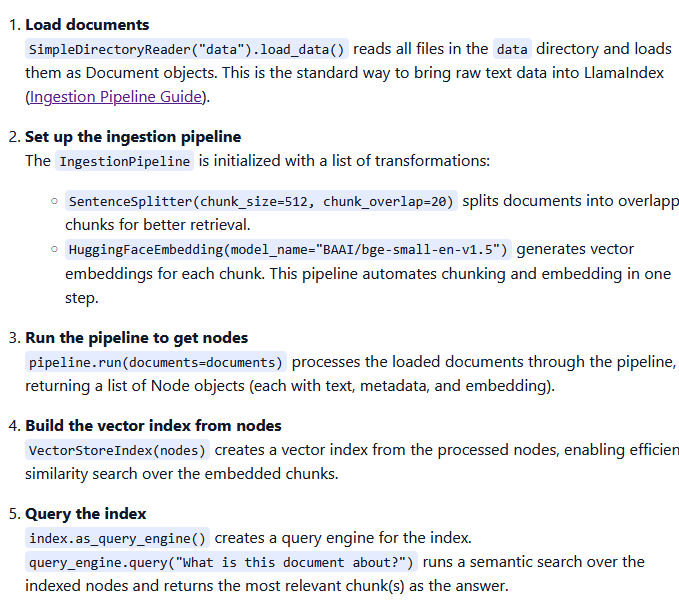

## USing PGVector store

In [28]:
# Exercise: Do this example:
# https://developers.llamaindex.ai/python/framework/integrations/vector_stores/postgres/

<b>Exercise</b> Do this [example](https://developers.llamaindex.ai/python/framework/integrations/vector_stores/postgres/), especioally the Hybrid Search

In [6]:
# 6.0 Install module
!pip install llama-index-vector-stores-postgres


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
# 6.1
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, StorageContext
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.ingestion import IngestionPipeline
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.vector_stores.postgres import PGVectorStore

In [9]:
# 6.2 Load documents
path = "/mnt/c/Users/ashok/OneDrive/Documents/llamaindex/revised19042026/"
documents = SimpleDirectoryReader(path+"data").load_data()

In [19]:
# 7.0
from llama_index.core import Settings
Settings.embed_model = HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5")

# Using Ollama

# 7.1 Call libraries
from llama_index.llms.ollama import Ollama

# 7.2 Configure the model
llm = Ollama(model="llama3.2:latest",
             request_timeout=120.0,
             temperature = 0.9
            )
Settings.llm = llm


2026-04-19 13:13:32,677 - INFO - Load pretrained SentenceTransformer: BAAI/bge-small-en-v1.5
2026-04-19 13:13:36,483 - INFO - 1 prompt is loaded, with the key: query


In [13]:
# 8.0  Set up the ingestion pipeline
pipeline = IngestionPipeline(
    transformations=[
        SentenceSplitter(chunk_size=512, chunk_overlap=20),
        HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5"),
    ]
)

2026-04-19 13:07:19,870 - INFO - Load pretrained SentenceTransformer: BAAI/bge-small-en-v1.5
2026-04-19 13:07:23,939 - INFO - 1 prompt is loaded, with the key: query


In [14]:
# 8.1 Run the pipeline to get nodes
nodes = pipeline.run(documents=documents)

# 8.2 Set up the Postgres vector store
vector_store = PGVectorStore.from_params(
                                        database="harnal",
                                        host="localhost",
                                        password="harnal",
                                        port=5432,
                                        user="harnal",
                                        table_name="my_vector_table",
                                        embed_dim=384,  # match your embedding dimension
                                    )


In [17]:
# 9. Build the vector index from nodes, using StorageContext
storage_context = StorageContext.from_defaults(vector_store=vector_store)
index = VectorStoreIndex(nodes, storage_context=storage_context)

In [21]:

# 10. Query the index
query_engine = index.as_query_engine()
response = query_engine.query("What are these two documents about? Decribe each one very briefly")
print(response)


2026-04-19 13:14:40,663 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


These two documents appear to be a research paper or academic manuscript, likely from a programming or computer science context. 

One document seems to describe experimental results of a machine learning model called MetaGPT on various software development tasks. The table provides statistical summaries of the results, comparing different metrics such as code statistics and prompt token usage.

The other document appears to be the same research paper, with an incomplete table showing further experimental results of the MetaGPT model on software development tasks.


In [ ]:
########### DONE #######